In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, skew
import os

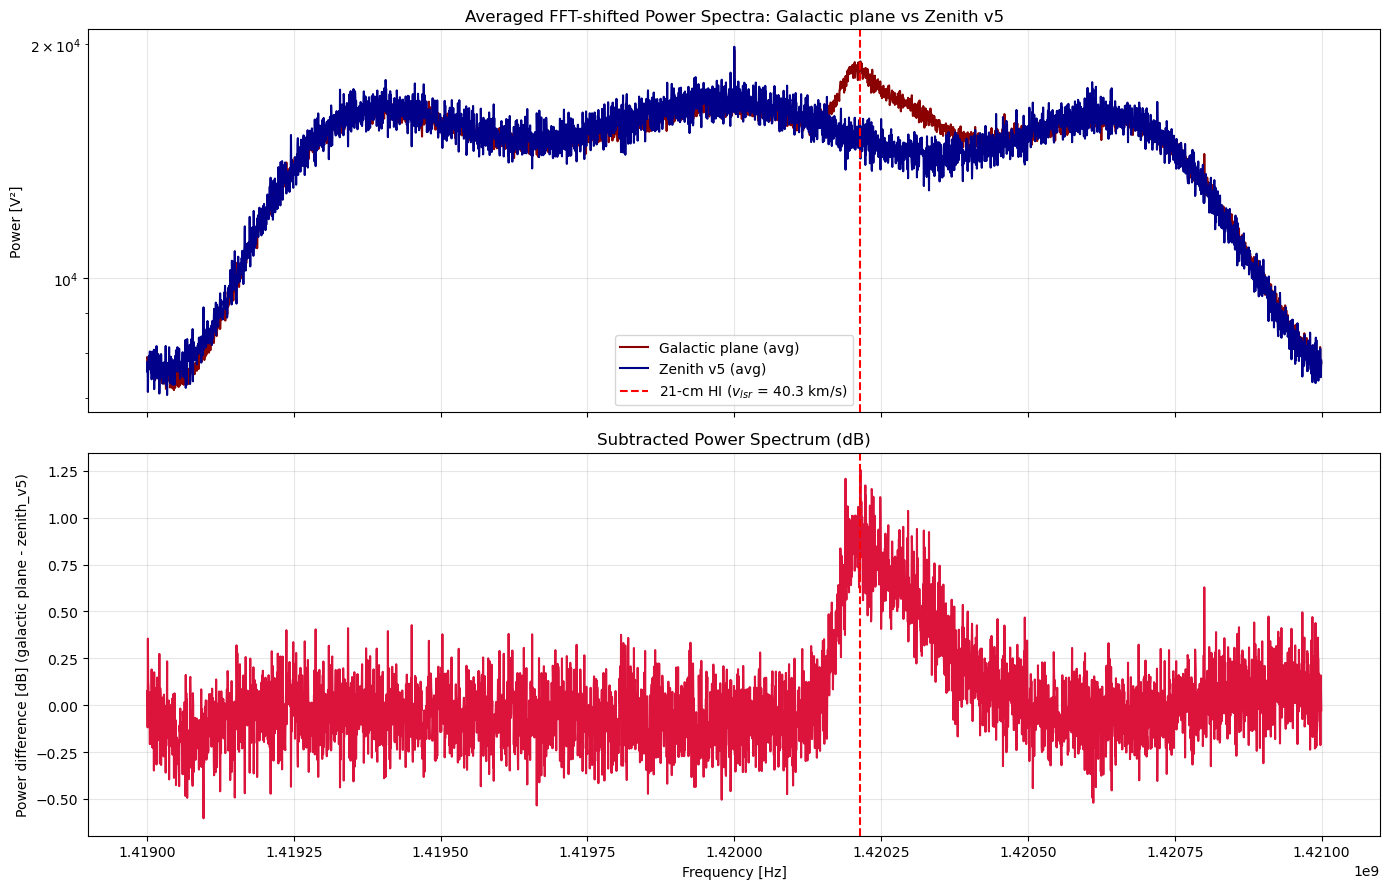

Max dB difference: 1.254 dB at 1.420e+09 Hz
Min dB difference: -0.604 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png


In [2]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_gal = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/bighorn_galactic_plane.npz"
fn_zen_v5 = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/bighorn_zenith_v5.npz"

data_gal = np.load(fn_gal)
data_zen_v5 = np.load(fn_zen_v5)

samples_gal = data_gal["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) / N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_gal, Pgal = avg_shifted_power(samples_gal, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_gal) != len(freq_zen_v5) or not np.allclose(freq_gal, freq_zen_v5):
    fmin = max(freq_gal.min(), freq_zen_v5.min())
    fmax = min(freq_gal.max(), freq_zen_v5.max())
    npts = min(len(freq_gal), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pgal_i = np.interp(f_common, freq_gal, Pgal)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pgal_plot = Pgal_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_gal
    Pgal_plot = Pgal
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pgal_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pgal_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,9), sharex = True)
ax1.plot(f_plot, Pgal_plot, label = 'Galactic plane (avg)', color = 'darkred')
ax1.plot(f_plot, Pzen_v5_plot, label = 'Zenith v5 (avg)', color = 'darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Galactic plane vs Zenith v5')
ax1.grid(True, alpha = 0.3)
ax1.axvline(f_HI, color = 'red', linestyle = '--', label = f'21-cm HI ($v_{{lsr}}$ = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (galactic plane - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha = 0.3)
ax2.axvline(f_HI, color = 'red', linestyle = '--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok = True)
outfn = 'Lab 2/figures/galactic_plane_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi = 300, bbox_inches = 'tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

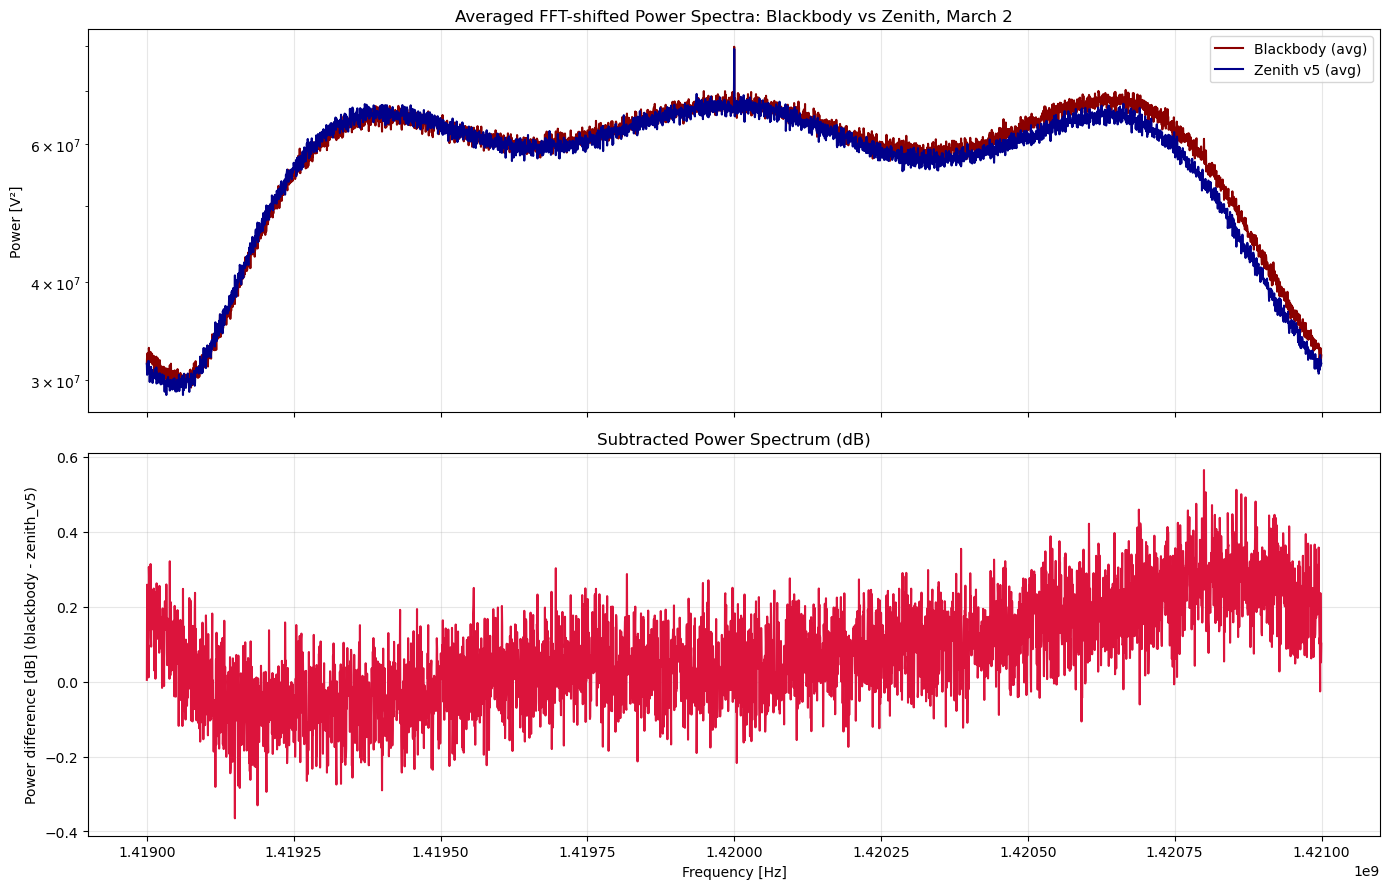

Max dB difference: 0.565 dB at 1.421e+09 Hz
Min dB difference: -0.365 dB at 1.419e+09 Hz
HI line frequency (adjusted): 1.420215e+09 Hz
Doppler shift: 40.32 km/s
Saved figure: Lab 2/figures/blackbody_minus_zenith_v5_difference.png


In [16]:
# Subtracted averaged fftshifted power spectrum: galactic plane - zenith v5
# Loads `bighorn_galactic_plane.npz` and `bighorn_zenith_v5.npz`, averages fftshifted power per block, subtracts and plots
# Includes Doppler shift for HI line based on velocity

# === Doppler/redshift parameters ===
f_HI_rest = 1420.40575177e6  # Rest frequency of 21 cm HI line [Hz]
c = 3e8  # Speed of light [m/s]
v_lsr = 40.32  # Line-of-sight velocity relative to LSR [km/s]. Positive = receding, Negative = approaching

# Convert velocity to frequency shift (Doppler formula, non-relativistic approximation valid for v << c)
# For small velocities: Δf/f ≈ -v/c (negative because receding increases wavelength)
f_HI = f_HI_rest * (1.0 - v_lsr * 1000 / c)  # Convert km/s to m/s

fn_body = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 Data/bighorn_blackbody_0302 (1).npz"
fn_zen_v5 = "C:/Users/medin/Downloads/Spring_2026/ASTRON121/LAB2/DATA/3-2 Data/bighorn_zenith_0302.npz"

data_body = np.load(fn_body)
data_zen_v5 = np.load(fn_zen_v5)

samples_body = data_body["samples"]
samples_zen_v5 = data_zen_v5["samples"]

fs_local = 2e6
f_offset = 1420e6

# helper to compute averaged fftshifted power
def avg_shifted_power(samples_arr, fs):
    num_blocks = samples_arr.shape[0]
    N = samples_arr.shape[1]
    acc = np.zeros(N, dtype=float)
    for i in range(num_blocks):
        blk = samples_arr[i]
        x_blk = blk[:,0] + 1j*blk[:,1]
        X_blk = np.fft.fft(x_blk)
        Xs = np.fft.fftshift(X_blk)
        P = (np.abs(Xs)**2) #/ N
        acc += P
    Pavg = acc / num_blocks
    freqs = np.fft.fftfreq(N, 1/fs)
    freqs_shift = np.fft.fftshift(freqs) + f_offset
    return freqs_shift, Pavg

freq_body, Pbody = avg_shifted_power(samples_body, fs_local)
freq_zen_v5, Pzen_v5 = avg_shifted_power(samples_zen_v5, fs_local)

# align frequency axes if needed
if len(freq_body) != len(freq_zen_v5) or not np.allclose(freq_body, freq_zen_v5):
    fmin = max(freq_body.min(), freq_zen_v5.min())
    fmax = min(freq_body.max(), freq_zen_v5.max())
    npts = min(len(freq_body), len(freq_zen_v5))
    f_common = np.linspace(fmin, fmax, npts)
    Pbody_i = np.interp(f_common, freq_body, Pbody)
    Pzen_v5_i = np.interp(f_common, freq_zen_v5, Pzen_v5)
    f_plot = f_common
    Pbody_plot = Pbody_i
    Pzen_v5_plot = Pzen_v5_i
else:
    f_plot = freq_body
    Pbody_plot = Pbody
    Pzen_v5_plot = Pzen_v5

# subtraction
Pdiff = Pbody_plot - Pzen_v5_plot
Pdiff_db = 10*np.log10(Pbody_plot + 1e-20) - 10*np.log10(Pzen_v5_plot + 1e-20)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,9), sharex = True)
ax1.plot(f_plot, Pbody_plot, label = 'Blackbody (avg)', color = 'darkred')
ax1.plot(f_plot, Pzen_v5_plot, label = 'Zenith v5 (avg)', color = 'darkblue')
ax1.set_yscale('log')
ax1.set_ylabel('Power [V²]')
ax1.set_title('Averaged FFT-shifted Power Spectra: Blackbody vs Zenith, March 2')
ax1.grid(True, alpha = 0.3)
#ax1.axvline(f_HI, color = 'red', linestyle = '--', label = f'21-cm HI ($v_{{lsr}}$ = {v_lsr:.1f} km/s)')
ax1.legend()

ax2.plot(f_plot, Pdiff_db, color='crimson')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Power difference [dB] (blackbody - zenith_v5)')
ax2.set_title('Subtracted Power Spectrum (dB)')
ax2.grid(True, alpha = 0.3)
#ax2.axvline(f_HI, color = 'red', linestyle = '--')

plt.tight_layout()

os.makedirs('Lab 2/figures', exist_ok = True)
outfn = 'Lab 2/figures/blackbody_minus_zenith_v5_difference.png'
plt.savefig(outfn, dpi = 300, bbox_inches = 'tight')
plt.show()

# report peaks
imax = np.argmax(Pdiff_db)
imin = np.argmin(Pdiff_db)
print(f"Max dB difference: {Pdiff_db[imax]:.3f} dB at {f_plot[imax]:.3e} Hz")
print(f"Min dB difference: {Pdiff_db[imin]:.3f} dB at {f_plot[imin]:.3e} Hz")
print(f"HI line frequency (adjusted): {f_HI:.6e} Hz")
print(f"Doppler shift: {v_lsr:.2f} km/s")
print(f"Saved figure: {outfn}")

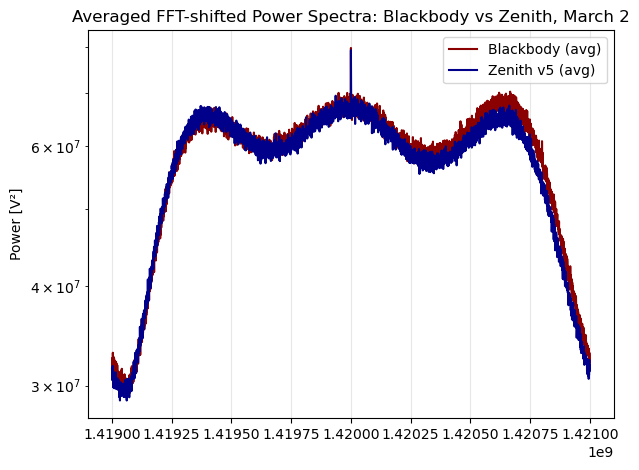

In [13]:
#fig, (ax1, ax2) = plt.subplots(2,1,figsize = (14,9), sharex = True)
plt.plot(f_plot, Pbody_plot, label = 'Blackbody (avg)', color = 'darkred')
plt.plot(f_plot, Pzen_v5_plot, label = 'Zenith v5 (avg)', color = 'darkblue')
plt.yscale('log')
plt.ylabel('Power [V²]')
plt.title('Averaged FFT-shifted Power Spectra: Blackbody vs Zenith, March 2')
plt.grid(True, alpha = 0.3)
#ax1.axvline(f_HI, color = 'red', linestyle = '--', label = f'21-cm HI ($v_{{lsr}}$ = {v_lsr:.1f} km/s)')
plt.legend()
plt.tight_layout()
